# Downscaling with Flow Matching - Inference Tutorial
* Author: James Redman
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-13
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Introduction

This notebook walks through running inference with two pre-trained flow matching models for downscaling precipitation over South Africa. We again use the CORDEXBench dataset over the South Africa domain. The models are trained on the full set of 15 atmospheric variables and orography, and generate realistic high-resolution rainfall fields.

Unlike the UNet downscaling model considered previously, these are generative models. Rather than producing a single output, they learn the distribution of plausible fields consistent with the coarse input. This means multiple different realisations can be drawn from the same output, capturing uncertainty in the downscaled field.

The two models available are:
- 'historical': trained on historical climate data only
- 'hitstorical_and_future': trained on both historical and future data

By the end of this notebook you will have:
1. Loaded a pretrained model and its data transforms
2. Run inference over the full test period
3. Visualised the samples produced against the RCM target field

This model has been developed for the Met Office by Tomas Wetherell, 2025.

In [1]:
import random

import numpy as np
import torch
import xarray as xr

import importlib.resources as resources
import yaml
import pathlib

import json
from abc import ABC, abstractmethod
from typing import Any
from collections.abc import Mapping

from torch.nn import Module
from torch import Tensor
from einops import rearrange
import math

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pprint

In [2]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda:0


## 1. Setup

### 1.1 Experiment selection

Choose which pre-trained model to load by setting 'experiment' to either 'historical' or 'historical_and_future'.

In [3]:
# Experiment choice: either 'historical' or 'historical_and_future'
experiment = 'historical'

### 1.2 Inference parameters

The parameters below control how inference is run.
- `n_samples`: how many independent precipitation fields to generate for each input. Since the model is generative, each sample will be slightly different
- `batch_size`: how many time steps to process at once. Reduce this if you run out of memory.
- `num_workers`: number of parallel data loading processes.

In [4]:
# Number of predictions to make for each time step
n_samples = 3

batch_size = 4
num_workers = 0

### 1.3 Paths

Specify **your** output directory below - model predictions will be saved here. The paths to the pretrained model weights are resolved automatically from the experiment choice.

In [5]:
# Outputs path - where model predictions are saved
output_path = pathlib.Path('/gws/nopw/j04/mohc_shared/users/kate_brown/cordexbench/flow_matching/outputs')
output_path.mkdir(parents=True, exist_ok=True)
print(f'Outputs will be saved to: {output_path}')

Outputs will be saved to: /gws/nopw/j04/mohc_shared/users/kate_brown/cordexbench/flow_matching/outputs


In [6]:
# Model paths - resolved automatically from experiment choice
flow_matching_base_path = pathlib.Path('/gws/ssde/j25a/mmh_storage/ai4c_data/flow_matching/sa_hackathon/')
experiment_path = flow_matching_base_path / f'sa_{experiment}'

config_path = experiment_path / 'emulator.yaml'
model_path = experiment_path / 'model.pth'
predictor_transforms_path = experiment_path / 'predictor_transforms.json'
target_transforms_path = experiment_path / 'target_transforms.json'

# CORDEXBench input data
predictors_path = pathlib.Path('/gws/ssde/j25a/mmh_storage/ai4c_data/cordexbench/SA_domain/train/Emulator_hist_future/predictors/ACCESS-CM2_1961-1980_2080-2099.nc')
targets_path = pathlib.Path('/gws/ssde/j25a/mmh_storage/ai4c_data/cordexbench/SA_domain/train/Emulator_hist_future/target/pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc')
static_fields_path = flow_matching_base_path / 'Static_fields.nc'

### 1.4 Model configuration

The emulator `.yaml` file, above, contains information on the particular configuration used to train the model. Note in particular the years used for training and validation, as well as the years which will be used for model testing.

In [7]:
# Load model configution
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

targets: list[str] = list(config["targets"].keys())
pprint.pprint(f"Configuration:\n{config}")

('Configuration:\n'
 "{'predictors': {'u_850': {'transforms': [{'name': 'normalisation', 'dims': "
 "['time', 'lat', 'lon']}]}, 'u_700': {'transforms': [{'name': "
 "'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'u_500': {'transforms': "
 "[{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'v_850': "
 "{'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, "
 "'v_700': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', "
 "'lon']}]}, 'v_500': {'transforms': [{'name': 'normalisation', 'dims': "
 "['time', 'lat', 'lon']}]}, 'q_850': {'transforms': [{'name': "
 "'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'q_700': {'transforms': "
 "[{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'q_500': "
 "{'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, "
 "'t_850': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', "
 "'lon']}]}, 't_700': {'transforms': [{'name': 'normalisation', 'di

## 2. Data Transforms

The model was **not** trained directly on raw data. All variables were first normalised to make the learning problem easier.

Predictor variables (Excluding orography) are Z-score normalised (rescaled to have zero mean and unit standard devaition). This keeps all input channels on a consistent scale regardless of their physcial units.

The target variable, precipitation, undergoes two transformations:
1. Log transform: precipitation is strictly non-negative and highly skewed. Mapping x to log(1+x) compresses the large values and spreads out the small ones, giving a more balanced distribution.
2. Z-score normalisation: the log-transformed values are then rescaled to have zero mean and unit standard deviation.

It's worth noting that unlike the UNet approach of per-sample normalisation, here we compute one single mean and standard deviation for each predictor/target. These are computed on the training dataset and saved alongside the model - they are loaded from file here rather than being recomputed.

During inference, these transforms are applied in the forward direction when loading data, and reversed when converting model outputs back to physical units (mm/day)

### 2.1 Base transform class

All transforms defined below share a common interface defined by the abstract class below.

In [8]:
class Transform(ABC):
    def __init__(self, **kwargs): ...

    @abstractmethod
    def fit(self, data: xr.DataArray) -> None:
        """Compute any statistics needed to parameterise the transform.

        Args:
            data: Data array to fit the transform on; typically the training data for a variable.
        """

    @abstractmethod
    def transform(self, data: xr.DataArray) -> xr.DataArray: ...

    @abstractmethod
    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray: ...

    @abstractmethod
    def state_dict(self) -> dict[str, Any]:
        """Return a dictionary capturing the state of the transform.

        Returns:
            A dictionary containing all parameters needed to re-instantiate the transform,
            including any statistics computed during `fit`.
        """

    @abstractmethod
    def load_state_dict(self, state: Mapping[str, Any]):
        """Load a previously saved transform state.

        Args:
            state: A mapping containing all parameters needed to re-instantiate the transform.
        """

### 2.2 Log transform

Applies 'log(1+x)' in the forward direction and 'exp(x)-1' in the reverse. This transform has no learnable parameters.

In [9]:
class Log1pTransform(Transform):
    def fit(self, data: xr.DataArray) -> None:
        pass

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        if (data < -1).any():
            raise ValueError("Log1pTransform input contains NaNs or values < -1.")
        return np.log1p(data)

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        return np.expm1(data)

    def state_dict(self) -> dict[str, Any]:
        return {"name": "log1p"}

    def load_state_dict(self, state: Mapping[str, Any]):
        pass

### 2.3 Normalisation transform

Z-score normalistion rescales the data to have zero mean and unit standard deviation.

In [10]:
class NormalisationTransform(Transform):
    """Z-score normalisation transform."""

    def __init__(self, dims: list[str], **kwargs):
        self.dims = dims  # Dimensions to compute mean and std over
        self.mean = None
        self.std = None

    def fit(self, data: xr.DataArray) -> None:
        """Compute mean and std over specified dimensions, ignoring NaNs."""
        self.mean = float(data.mean(dim=self.dims, skipna=True).compute())
        self.std = max(
            float(data.std(dim=self.dims, skipna=True).compute()), 1e-6
        )  # Avoid division by zero

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        return (data - self.mean) / self.std

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        return data * self.std + self.mean

    def state_dict(self) -> dict:
        return {"name": "normalisation", "dims": self.dims, "mean": self.mean, "std": self.std}

    def load_state_dict(self, state: dict):
        self.dims = state["dims"]
        self.mean = state["mean"]
        self.std = state["std"]

### 2.4 Clip transform

Reversing the normalistation transform can produce small negative precipitation values. This transform clips model outputs so they lie in a physcially plauaible range. Note that it only acts in inverse direction on model outputs.

In [11]:
class ClipOutputsTransform(Transform):
    """Clip model outputs to a specified min and max value.

    Note that this transform is a no-op during the `transform` step, and is only applied during
    `inverse_transform`. It is useful when the model outputs may be outside a valid range, e.g.
    negative precipitation values after reversing a normalisation transform (when using a model
    trained in normalised space).

    In most cases, this transform should be placed at the *start* of the list of transforms for
    an output variable, so that it is the last transform applied during inverse_transform.
    """

    def __init__(self, min: float | None = None, max: float | None = None, **kwargs):
        """Initialise.

        Args:
            min: Minimum value to clip to. If None, no minimum clipping is applied.
            max: Maximum value to clip to. If None, no maximum clipping is applied.

        Raises:
            ValueError: If min is not less than max.
        """
        self.min = min
        self.max = max

        if self.min is not None and self.max is not None:
            if self.min >= self.max:
                raise ValueError(f"ClipOutputsTransform min {self.min} must be < max {self.max}.")

    def fit(self, data: xr.DataArray) -> None:
        pass

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        # No-op during transform. This transform is to clip model outputs only.
        return data

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        return np.clip(data, self.min, self.max)

    def state_dict(self) -> dict:
        return {"name": "clip_outputs", "min": self.min, "max": self.max}

    def load_state_dict(self, state: dict):
        self.min = state["min"]
        self.max = state["max"]

### 2.5 Composed transform

This transform is used to compose several transforms together, such as for precipitaion which is log-transformed as well as Z-score normalised.

In [12]:
class ComposeTransform(Transform):
    """Compose several transforms together."""

    def __init__(self, transforms: list[Transform]):
        self.transforms = transforms

    def fit(self, data: xr.DataArray) -> None:
        for t in self.transforms:
            t.fit(data)
            data = t.transform(data)

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        for t in self.transforms:
            data = t.transform(data)
        return data

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        for t in reversed(self.transforms):
            data = t.inverse_transform(data)
        return data

    def state_dict(self) -> dict:
        return {
            "name": "compose",
            "transforms": [transform.state_dict() for transform in self.transforms],
        }

    def load_state_dict(self, state: dict):
        for transform, transform_state in zip(self.transforms, state["transforms"]):
            transform.load_state_dict(transform_state)

### 2.6 Loading saved transfroms

The functions below load the saved tranform parameters from the predictor and target JSON files stored alongside the model. These were fitted on the training data and are reused here so that the same normalisation is applied during inference.

We also print the mean and std used for normalising each variable.

In [13]:
TRANSFORM_REGISTRY = {
    "log1p": Log1pTransform,
    "normalisation": NormalisationTransform,
    "clip_outputs": ClipOutputsTransform,
}
"""Mapping from transform names to classes."""

def _load_transform_from_state(state: dict) -> Transform:
    """Instantiate a transform from a state dictionary

    Args:
        state: Dictionary which captures state required to instantiate a Transformation,
            including any previously-computed statistics, e.g,
            ```
            {
                "name": "normalisation,
                "dims": ["time", "grid_latitude", "grid_longitude"],
                "mean: 0.74,
                "std": 0.93
            }
            ```

    Returns:
        Transform instance with loaded state.

    Raises:
        ValueError: If the transform name is not "compose" or not in the TRANSFORM_REGISTRY.
    """
    name = state["name"]

    if name == "compose":
        transforms = []
        for transform_state in state["transforms"]:
            transforms.append(_load_transform_from_state(transform_state))
        return ComposeTransform(transforms)

    elif name in TRANSFORM_REGISTRY:
        transform = TRANSFORM_REGISTRY[name](**state)
        transform.load_state_dict(state)
        return transform

    else:
        raise ValueError(f"Unknown transform: {name}")


def load_transforms(path: str) -> dict[str, Transform]:
    """Load transforms from a JSON file.

    Args:
        path: Full path to the JSON file containing the transforms.

    Returns:
        transform_map: Dictionary mapping from variable name to a Transform instance with loaded
            state.
    """
    with open(path) as fh:
        states = json.load(fh)

    transform_map: dict[str, dict[str, Transform]] = {}
    for group, group_states in states.items():
        transform_map[group] = {
            var_name: _load_transform_from_state(state) for var_name, state in group_states.items()
        }

    return transform_map

In [14]:
transforms: dict[str, dict[str, Transform]] = {
    "predictors": load_transforms(predictor_transforms_path)["predictors"],
    "targets": load_transforms(target_transforms_path)["targets"],
}

# Print the normalisation parameters for each variable
print("Predictor transforms:")
for var, transform in transforms["predictors"].items():
    norm = transform.transforms[0]  # single NormalisationTransform
    print(f"  {var}: mean={norm.mean:.4f}, std={norm.std:.4f}")

print("\nTarget transforms:")
for var, transform in transforms["targets"].items():
    for t in transform.transforms:
        if isinstance(t, NormalisationTransform):
            print(f"  {var}: mean={t.mean:.4f}, std={t.std:.4f} (in log space)")

Predictor transforms:
  u_850: mean=-0.0474, std=6.0398
  u_700: mean=3.5333, std=7.4192
  u_500: mean=7.9441, std=10.6967
  v_850: mean=-0.5784, std=5.0288
  v_700: mean=-0.8856, std=4.8264
  v_500: mean=-0.6596, std=6.3598
  q_850: mean=0.0074, std=0.0040
  q_700: mean=0.0045, std=0.0031
  q_500: mean=0.0016, std=0.0014
  t_850: mean=290.5735, std=7.5655
  t_700: mean=281.9147, std=5.8967
  t_500: mean=265.8841, std=5.8186
  z_850: mean=1535.6869, std=51.9964
  z_700: mean=3165.2339, std=59.8972
  z_500: mean=5868.2695, std=108.5456

Target transforms:
  pr: mean=0.6465, std=0.9561 (in log space)


## 3. Dataset

The 'CordexBenchDataset' class handles loading and preprocessing the CORDEXBench data. For each time step it:
1. Loads the coarse scale predictors and applies the transforms
2. Upscales the predictors from the coarse (16x16) to the target (128x128) grid via bilinear interpolation (this is done so the high-resolution (128x128) ororgaphy field can be appended to the predictors without coarsening and losing resolution)
3. Appends a normalised orography field as an additional channel
4. Loads and transforms the high-resolution target variable

In [15]:
class CordexBenchDataset(torch.utils.data.Dataset):
    """Dataset for CordexBench."""

    def __init__(
        self,
        predictors_path: str,
        config: dict,
        transforms: dict[str, dict[str, Transform]],
        years: list[str],
        targets_path: str | None = None,
        static_fields_path: str | None = None,
    ):
        """
        Initialise.

        Args:
            predictors_path: Path to netcdf file containing predictor variables.
            config: Configuration dictionary.
            transforms: Mapping from group name to dictionary of variable name to Transform.
            years: List of year range strings (e.g., "1961-1970") or individual year strings
                (e.g., "2032") to include in the dataset.
            targets_path: Path to netcdf file containing target variables. If None, zero-tensor
                placeholders are returned for targets.
            static_fields_path: Path to netcdf file containing static fields. If None,
                no static fields are used.
        """
        self.transforms = transforms
        self.config = config

        self.predictors = list(config["predictors"].keys())
        self.targets = list(config["targets"].keys())

        self.year_ranges = self._parse_years(years)

        predictors_ds = xr.open_dataset(predictors_path)
        self.predictors_ds = self._restrict_to_years(predictors_ds, self.year_ranges)

        self.targets_ds: xr.Dataset | None = None
        if targets_path is not None:
            targets_ds = xr.open_dataset(targets_path)
            self.targets_ds = self._restrict_to_years(targets_ds, self.year_ranges)

        self.orography: torch.Tensor | None = None
        if static_fields_path is not None:
            static_ds = xr.open_dataset(static_fields_path)
            orography = static_ds["orog"].values
            # Min-max normalisation
            orography = (orography - orography.min()) / (orography.max() - orography.min())
            self.orography = torch.tensor(orography, dtype=torch.float32).unsqueeze(
                0
            )  # shape (1, lat, lon)

        self.length = self.predictors_ds.sizes["time"]
        #logger.info(f"CordexBenchDataset initialized with {self.length} samples.")

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return a sample from the dataset.

        Transforms are applied. Predictors are upscaled to match target spatial
        resolution (lat, lon).

        Args:
            idx: Index of the sample to retrieve.

        Returns:
            predictors: Tensor of conditioning variables, shape (no. conditioning variables, lat, lon)
            targets: Tensor of target variables, shape (no. targets, lat, lon)
        """
        # Load predictors

        predictors_sample = self.predictors_ds[self.predictors].isel(time=idx)
        predictors = self._get_group_tensor(predictors_sample, self.predictors, "predictors")

        # Upscale predictors to match target spatial resolution (16x16 -> 128x128)
        predictors = torch.nn.functional.interpolate(
            predictors.unsqueeze(
                0
            ),  # interpolate expects batch dimension, so we temporarily add one
            scale_factor=8,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)  # shape back to (no. conditioning variables, lat, lon)

        # Append orography field to predictors if available
        if self.orography is not None:
            predictors = torch.cat([predictors, self.orography], dim=0)

        # Load targets

        if self.targets_ds is None:
            # Return zero-tensor placeholders for targets
            targets = torch.zeros(
                (len(self.targets), predictors.shape[1], predictors.shape[2]), dtype=torch.float32
            )
        else:
            targets_sample = self.targets_ds[self.targets].isel(time=idx)
            targets = self._get_group_tensor(targets_sample, self.targets, "targets")


        return predictors, targets

    def _get_group_tensor(
        self, sample: xr.Dataset, variables: list[str], name: str
    ) -> torch.Tensor:
        """Get a tensor for a group of variables.

        Args:
            sample: Dataset sample containing the variables.
            variables: List of variable names to retrieve.
            name: Name of the group, one of "predictors", "targets" or "source".

        Returns:
            group_tensor: Tensor containing the transformed values of the specified variables.
                Shape (no. variables, lat, lon).
        """
        tensors: list[torch.Tensor] = []

        for var in variables:
            # Force load the data from disk into memory explicitly.
            # This ensures we get an efficient slab read from the NetCDF file
            # before any arithmetic transforms construct a complex graph.
            data = sample[var].load()

            transformed = torch.tensor(
                self.transforms[name][var].transform(data).values, dtype=torch.float32
            )
            tensors.append(transformed)

        group_tensor = torch.stack(tensors)

        return group_tensor

    def _restrict_to_years(self, ds: xr.Dataset, year_ranges: list[tuple[int, int]]) -> xr.Dataset:
        """Restrict dataset to the specified year range(s)."""
        masks = []
        years = ds["time"].dt.year

        for start, end in year_ranges:
            masks.append((years >= start) & (years <= end))

        combined_mask = masks[0]
        for mask in masks[1:]:
            combined_mask = combined_mask | mask

        return ds.sel(time=combined_mask)

    def _parse_years(self, years: list[str]) -> list[tuple[int, int]]:
        """Parse year ranges or individual years from strings to tuples of integers.

        Args:
            years: List of year range strings (e.g., "1961-1970") or individual year strings
                (e.g., "2032").

        Returns:
            year_ranges: List of tuples of integers representing the year ranges,
                e.g. [(1961, 1970), (2032, 2032)].
        """
        year_ranges = []
        for year_spec in years:
            if "-" in year_spec:
                # Handle a range, e.g., "1961-1970"
                start_year_str, end_year_str = year_spec.split("-")
                start_year = int(start_year_str)
                end_year = int(end_year_str)
            else:
                # Handle a single year, e.g., "2032"
                single_year = int(year_spec)
                start_year = single_year
                end_year = single_year

            year_ranges.append((start_year, end_year))
        return year_ranges

### 3.1 Initiatlising the test datset

The dataset is initialised using the test years specified in the model config.

In [16]:
test_dataset = CordexBenchDataset(
        predictors_path=predictors_path,
        config=config,
        transforms=transforms,
        years=config["test"]["years"],
        targets_path=targets_path,
        static_fields_path=static_fields_path,
    )
print(f"Test years:   {config['test']['years']}")

Test years:   ['1979-1980', '2080', '2099']


### 3.2 Data Loader

The DataLoader batches the dataset for inference. Shuffling is disabled to preserve the time ordering of predicitions.

In [17]:
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

## 4. Network

During inference the model starts from Gaussian noise and iteratively generates a high resolution precipitation field. This is done over several steps. At each step, the model knows the current state of the nosiy precipitation field, the time parameterising the flow, and the conditioning predictors. We need to evaluate a velocity field which tells the noisy precipitaion field in which direction to move in the next denoising step. This function is parameterised by a neural network which is very similar to a UNet and is built up from the classes defined below.

### 4.1 Time embedding

The scalar time 't' which parametrises the flow from 't=0' to 't=1' needs to be mapped to a higher dimension before it can be injected into the network.

In [18]:
class FourierEmbedding(Module):
    """Fourier Embedding.

    FE(t) = [sin(2 * pi * t * w_1), cos(2 * pi * t * w_1), ..., sin(2 * pi * t * w_d/2), cos(2 * pi * t * w_d/2)] * sqrt(2),
    where w_i are the weights of the Fourier embedding and t is a scalar time in [0, 1].
    """

    def __init__(self, dim: int, learnable: bool = False):
        """Initialise.

        Args:
            dim: Dimension of the output embedding. Must be even.
            learnable: If True, the weights will be learnable parameters. If False, they
                will be fixed random values drawn from a normal distribution.
        """
        super().__init__()
        assert dim % 2 == 0
        half_dim = dim // 2
        self.weights = torch.nn.Parameter(torch.randn(half_dim), requires_grad=learnable)

    def forward(self, t: Tensor) -> Tensor:
        """Embed time tensor using fourier embedding.

        Args:
            t: Times between 0 and 1, shape (batch_size, 1)

        Returns:
            Fourier embedding, shape (batch_size, dim)
        """
        freqs = t * rearrange(self.weights, "half_dim -> 1 half_dim") * 2 * math.pi
        return torch.cat((freqs.sin(), freqs.cos()), dim=-1) * math.sqrt(2)

### 4.2 Convolution layer

A standard 2D convolution layer with optional 2x upsampling or downsampling. This is used throughout the network.

In [19]:
class Conv2d(torch.nn.Module):
    """Convolution layer, with optional downsampling or upsampling."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        bias: bool = True,
        upsample: bool = False,
        downsample: bool = False,
        resample_filter: list[int] = [1, 1],
    ):
        """Inititalise block.

        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            kernel_size: Kernel size of convolution layer. If 0, no convolution is applied.
            bias: If True, add a bias term to the convolution layer.
            upsample: If True, upsample by a factor of 2.
            downsample: If True, downsample by a factor of 2.
            resample_filter: 1D kernel/filter for up/downsampling. Defaults to [1, 1], which is
                equivalent to average pooling.
        """
        assert not (upsample and downsample)
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.upsample = upsample
        self.downsample = downsample

        self.conv = (
            torch.nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                padding=kernel_size // 2 if kernel_size > 0 else 0,
                bias=bias,
            )
            if kernel_size > 0
            else None
        )

        f = torch.as_tensor(resample_filter, dtype=torch.float32)
        f = f.ger(f).unsqueeze(0).unsqueeze(1) / f.sum().square()
        self.register_buffer("resample_filter", f if upsample or downsample else None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Upsampling / downsampling
        f = self.resample_filter.to(x.dtype) if self.resample_filter is not None else None
        f_pad = (f.shape[-1] - 1) // 2 if f is not None else 0

        if self.upsample:
            x = torch.nn.functional.conv_transpose2d(
                x,
                f.mul(4).tile([self.in_channels, 1, 1, 1]),
                groups=self.in_channels,
                stride=2,
                padding=f_pad,
            )
        elif self.downsample:
            x = torch.nn.functional.conv2d(
                x,
                f.tile([self.in_channels, 1, 1, 1]),
                groups=self.in_channels,
                stride=2,
                padding=f_pad,
            )

        if self.conv is not None:
            x = self.conv(x)

        return x

### 4.3 Encoder and decoder

At each level the encoder halves the spatial resolution, while the number of channels increases. This forces the network to compress the input into increasingly abstract, large-scale representations. The decoder reverses this process, restoring spatial resolution progressively. At each level, feature maps from the corresponding encoder level are passed in via skip connections and concatenated with the decoder features. This means the spatial detail set aside in the encoding path is reintroduced at the corresponding level.

In [20]:
class Encoder(Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        emb_channels: int,
        downsample: bool = False,
        adaptive_scale: bool = True,
        resample_filter: list[int] = [1, 1],
        attention: bool = False,
        channels_per_head: int = 64,
        dropout: float = 0.0,
    ):
        """Initialise encoder block.

        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            emb_channels: Number of channels in the time embedding.
            downsample: If True, downsample by a factor of 2.
            adaptive_scale: If True, apply FiLM conditioning (scale and shift the input features).
                If False, apply additive conditioning (add the embedding to the input features).
            resample_filter: 1D kernel/filter for downsampling. Defaults to [1, 1], which is
                equivalent to average pooling.
            attention: If True, apply attention mechanism.
            channels_per_head: Number of channels per attention head, if attention is True.
            dropout: Dropout rate applied after the first convolution layer.
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.adaptive_scale = adaptive_scale

        # Affine transformation applied to time embedding
        self.affine = torch.nn.Linear(
            in_features=emb_channels,
            out_features=out_channels * (2 if adaptive_scale else 1),
            bias=True,
        )

        layers_pre_modulation: list[torch.nn.Module] = [
            torch.nn.GroupNorm(num_groups=32, num_channels=in_channels),
            torch.nn.SiLU(),
            Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                bias=True,
                downsample=downsample,
                resample_filter=resample_filter,
            ),
            torch.nn.GroupNorm(num_groups=32, num_channels=out_channels),
        ]
        self.layers_pre_modulation = torch.nn.Sequential(*layers_pre_modulation)

        layers_post_modulation: list[torch.nn.Module] = [
            torch.nn.SiLU(),
            torch.nn.Dropout(p=dropout),
            Conv2d(out_channels, out_channels, kernel_size=3, bias=True, downsample=False),
        ]
        self.layers_post_modulation = torch.nn.Sequential(*layers_post_modulation)

        # Skip connection
        if out_channels != in_channels or downsample:
            # Use 1x1 convolution if we need to change the number of channels.
            # Otherwise (if we're just downsampling), there is no convolution applied.
            kernel = 1 if out_channels != in_channels else 0
            self.skip = Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel,
                downsample=downsample,
                resample_filter=resample_filter,
            )
        else:
            # No need to modify the input if the number of channels is constant and no downsampling is applied.
            self.skip = torch.nn.Identity()

        # Multi-head self-attention
        self.attention = attention
        if self.attention:
            if out_channels % channels_per_head != 0:
                raise ValueError(
                    f"out_channels ({out_channels}) must be divisible by channels_per_head ({channels_per_head})"
                )
            self.num_heads = out_channels // channels_per_head
            self.norm2 = torch.nn.GroupNorm(num_groups=32, num_channels=out_channels)
            self.qkv = Conv2d(
                in_channels=out_channels, out_channels=out_channels * 3, kernel_size=1
            )
            self.proj = Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=1)

    def forward(self, x: Tensor, emb: Tensor) -> Tensor:
        """Forward pass.

        Args:
            x: Input tensor, shape (batch_size, in_channels, height, width)
            emb: Time embedding, shape (batch_size, emb_channels)

        Returns:
            x: Output tensor, shape (batch_size, out_channels, height', width'), where height' and
                width' depend on whether downsampling was applied (will be half the input size if downsample=True).
        """
        orig = x

        x = self.layers_pre_modulation(x)

        emb = rearrange(self.affine(emb), "bs c -> bs c 1 1")
        if self.adaptive_scale:
            # FiLM conditioning: scale and shift the input features
            scale, shift = torch.chunk(emb, 2, dim=1)
            x = x * (1 + scale) + shift  # identity if scale and shift are zero
        else:
            # Additive conditioning: add the embedding to the input features
            x = x + emb

        x = self.layers_post_modulation(x)
        x = self.skip(orig) + x

        if self.attention:
            q, k, v = (
                self.qkv(self.norm2(x))
                .reshape(x.shape[0] * self.num_heads, x.shape[1] // self.num_heads, 3, -1)
                .unbind(2)
            )

            scale = 1 / math.sqrt(k.size(1))
            w = torch.einsum("ncq,nck->nqk", q, k).mul_(scale)
            w = w.to(dtype=torch.float32).softmax(dim=2).to(dtype=q.dtype)
            a = torch.einsum("nqk,nck->ncq", w, v)

            x = self.proj(a.reshape(*x.shape)).add_(x)

        return x


class Decoder(Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        emb_channels: int,
        upsample: bool = False,
        adaptive_scale: bool = True,
        resample_filter: list[int] = [1, 1],
        attention: bool = False,
        channels_per_head: int = 64,
        dropout: float = 0.0,
    ):
        """Initialise decoder block.

        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            emb_channels: Number of channels in the time embedding.
            upsample: If True, upsample by a factor of 2.
            adaptive_scale: If True, apply FiLM conditioning (scale and shift the input features).
                If False, apply additive conditioning (add the embedding to the input features).
            resample_filter: 1D kernel/filter for upsampling.
            attention: If True, apply attention mechanism.
            channels_per_head: Number of channels per attention head, if attention is True.
            dropout: Dropout rate applied after the first convolution layer.
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.adaptive_scale = adaptive_scale

        # Affine transformation applied to time embedding
        self.affine = torch.nn.Linear(
            in_features=emb_channels,
            out_features=out_channels * (2 if adaptive_scale else 1),
            bias=True,
        )

        layers_pre_modulation: list[torch.nn.Module] = [
            torch.nn.GroupNorm(num_groups=32, num_channels=in_channels),
            torch.nn.SiLU(),
            Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                bias=True,
                upsample=upsample,
                resample_filter=resample_filter,
            ),
            torch.nn.GroupNorm(num_groups=32, num_channels=out_channels),
        ]
        self.layers_pre_modulation = torch.nn.Sequential(*layers_pre_modulation)

        layers_post_modulation: list[torch.nn.Module] = [
            torch.nn.SiLU(),
            torch.nn.Dropout(p=dropout),
            Conv2d(out_channels, out_channels, kernel_size=3, bias=True, upsample=False),
        ]
        self.layers_post_modulation = torch.nn.Sequential(*layers_post_modulation)

        # Skip connection
        if out_channels != in_channels or upsample:
            # Use 1x1 convolution if we need to change the number of channels.
            # Otherwise (if we're just upsampling), there is no convolution applied.
            kernel = 1 if out_channels != in_channels else 0
            self.skip = Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel,
                upsample=upsample,
                resample_filter=resample_filter,
            )
        else:
            # No need to modify the input if the number of channels is constant and no upsampling is applied.
            self.skip = torch.nn.Identity()

        # Multi-head self-attention
        self.attention = attention
        if self.attention:
            if out_channels % channels_per_head != 0:
                raise ValueError(
                    f"out_channels ({out_channels}) must be divisible by channels_per_head ({channels_per_head})"
                )
            self.num_heads = out_channels // channels_per_head
            self.norm2 = torch.nn.GroupNorm(num_groups=32, num_channels=out_channels)
            self.qkv = Conv2d(
                in_channels=out_channels, out_channels=out_channels * 3, kernel_size=1
            )
            self.proj = Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=1)

    def forward(self, x: Tensor, emb: Tensor) -> Tensor:
        """Forward pass.

        Args:
            x: Input tensor, shape (batch_size, in_channels, height, width)
            emb: Time embedding, shape (batch_size, emb_channels)

        Returns:
            x: Output tensor, shape (batch_size, out_channels, height', width'), where height' and
                width' depend on whether upsampling was applied (will be double the input size if upsample=True).
        """
        orig = x

        x = self.layers_pre_modulation(x)

        emb = rearrange(self.affine(emb), "bs c -> bs c 1 1")
        if self.adaptive_scale:
            # FiLM conditioning: scale and shift the input features
            scale, shift = torch.chunk(emb, 2, dim=1)
            x = x * (1 + scale) + shift  # identity if scale and shift are zero
        else:
            # Additive conditioning: add the embedding to the input features
            x = x + emb

        x = self.layers_post_modulation(x)
        x = self.skip(orig) + x

        if self.attention:
            q, k, v = (
                self.qkv(self.norm2(x))
                .reshape(x.shape[0] * self.num_heads, x.shape[1] // self.num_heads, 3, -1)
                .unbind(2)
            )

            scale = 1 / math.sqrt(k.size(1))
            w = torch.einsum("ncq,nck->nqk", q, k).mul_(scale)
            w = w.to(dtype=torch.float32).softmax(dim=2).to(dtype=q.dtype)
            a = torch.einsum("nqk,nck->ncq", w, v)

            x = self.proj(a.reshape(*x.shape)).add_(x)

        return x

### 4.4 The full network

The classes defined above are used to form the full network. At each step of the flow, the network takes three inputs:
- t: how far along the trajectory we are, from 0 (pure noise) to 1 (final output)
- x_t: the current state of the precipitation field (Starting as random noise)
- conditioning: the coarse predictors (+ orography)

These are concatenated channel-wise and passed through the network. The network outputs a velocity field (same shape as the precipitation field) which will be used to tell the solver how to update the noisy precipitation in the next step.


In [21]:
class ADM(Module):
    def __init__(
        self,
        num_conditioning_variables: int,
        num_target_variables: int,
        img_resolution: int = 64,
        model_channels: int = 192,
        channel_mult: list[int] = [1, 2, 3, 4],
        channel_mult_emb: int = 4,
        num_residual_blocks: int = 3,
        attention_resolutions: list[int] = [16, 8],
        dropout: float = 0.1,
    ):
        """
        Args:
            num_conditioning_variables: Number of conditioning variables.
            img_resolution: Resolution at input and output.
            model_channels: Base mutiplier for the number of channels.
            channel_mult: Per-resolution multipliers for the number of channels.
            channel_mult_emb: Multiplier for the dimensionality of the embedding vector.
            num_residual_blocks: Number of residual blocks per resolution.
            attention_resolutions: List of resolutions with self-attention.
            dropout: Dropout rate.
        """
        super().__init__()

        # The conditioning variables are concatenated with x_t (which has num_target_variables
        # channels).
        self.num_variables = num_conditioning_variables + num_target_variables
        self.num_target_variables = num_target_variables

        # Embedding
        emb_channels = model_channels * channel_mult_emb
        embedding_layers: list[torch.nn.ModuleDict] = [
            FourierEmbedding(dim=model_channels),
            torch.nn.Linear(in_features=model_channels, out_features=emb_channels, bias=True),
            torch.nn.SiLU(),
            torch.nn.Linear(in_features=emb_channels, out_features=emb_channels, bias=True),
            torch.nn.SiLU(),
        ]
        self.embedding = torch.nn.Sequential(*embedding_layers)

        # Encoder
        self.enc = torch.nn.ModuleDict()
        for level, mult in enumerate(channel_mult):
            res = img_resolution // (2**level)
            if level == 0:
                in_ch = self.num_variables
                out_ch = model_channels * mult
                self.enc[f"{res}x{res}_conv"] = Conv2d(
                    in_channels=in_ch, out_channels=out_ch, kernel_size=3
                )
            else:
                self.enc[f"{res}x{res}_down"] = Encoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    downsample=True,
                    attention=False,
                    dropout=dropout,
                )

            for idx in range(num_residual_blocks):
                in_ch = out_ch
                out_ch = model_channels * mult
                self.enc[f"{res}x{res}_block{idx}"] = Encoder(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    downsample=False,
                    attention=(res in attention_resolutions),
                    dropout=dropout,
                )
        skip_num_channels = [block.out_channels for block in self.enc.values()]

        # Decoder
        self.dec = torch.nn.ModuleDict()
        for level, mult in reversed(list(enumerate(channel_mult))):
            res = img_resolution // (2**level)
            if level == len(channel_mult) - 1:
                self.dec[f"{res}x{res}_mid1"] = Decoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    attention=True,
                    dropout=dropout,
                )
                self.dec[f"{res}x{res}_mid2"] = Decoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    attention=False,
                    dropout=dropout,
                )
            else:
                self.dec[f"{res}x{res}_up"] = Decoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    upsample=True,
                    attention=False,
                    dropout=dropout,
                )

            for idx in range(num_residual_blocks + 1):
                in_ch = out_ch + skip_num_channels.pop()
                out_ch = model_channels * mult
                self.dec[f"{res}x{res}_block{idx}"] = Decoder(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    upsample=False,
                    attention=(res in attention_resolutions),
                    dropout=dropout,
                )

        # Final output block
        self.out_block = torch.nn.Sequential(
            torch.nn.GroupNorm(num_groups=32, num_channels=out_ch),
            torch.nn.SiLU(),
            Conv2d(
                in_channels=out_ch, out_channels=self.num_target_variables, kernel_size=3, bias=True
            ),
        )

    def forward(self, x_t: Tensor, t: Tensor, conditioning: Tensor) -> Tensor:
        """Forward pass.

        Args:
            x_t: Samples from probability path, shape (batch_size, num_target_variables, height, width)
            t: Times between [0, 1], shape (batch_size, 1)
            conditioning: Conditioning variables, shape (batch_size, num_conditioning_variables, height, width)

        Returns:
            x: Velocity estimates, shape (batch_size, num_target_variables, height, width)
        """
        emb = self.embedding(t)  # shape (bs, emb_channels)

        x = torch.concat((x_t, conditioning), dim=1)

        # Encoder
        skips: torch.Tensor = []
        for block in self.enc.values():
            x = block(x, emb) if isinstance(block, Encoder) else block(x)
            skips.append(x)

        # Decoder
        for block in self.dec.values():
            if x.shape[1] != block.in_channels:
                x = torch.cat((x, skips.pop()), dim=1)
            x = block(x, emb)

        x = self.out_block(x)
        return x

### 4.5 Loading the pretrained model

We use the hyperparameters given in the config file and load the pretrained weights.

The `_orig_mod.` prefix is stripped from the saved weights names (artifact of the way the model was trained).

In [22]:
# Number of conditioning variables
num_conditioning_variables = len(config["predictors"]) + (1 if static_fields_path is not None else 0)

model = ADM(
    num_conditioning_variables=num_conditioning_variables,
    num_target_variables=len(config["targets"]),
    **config["model"],
).to(DEVICE)

# strip _orig_mod. prefix
state_dict = torch.load(model_path, map_location=DEVICE)
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

print(f"Loaded model with {sum(p.numel() for p in model.parameters()):,} parameters")

Loaded model with 50,716,993 parameters


## 5. Flow matching inference

The inference pipeline has three main steps:
1. Sample a starting point from Gaussian noise for each of the n_samples
2. Integrate the flow from t=0 to t=1 using the foward Euler method (calling the neural network at each step to get the velocity field)
3. Repeat for each batch of time steps until the full test period is complete

The result is a set of high-resolution precipitaion fields for each time step in the test set.

### 5.1 Source Sampler

The flow starts from a sample selected from a Gaussian distibution (pure noise) with the same dimension as the target field.

In [23]:
class DistributionSampler:
    """Sample from a distribution."""

    def __init__(self, config: dict, device: torch.device):
        """Initialise sampler.

        Args:
            config: Configuration dictionary containing source type and parameters.
            device: Device to perform computations on (e.g., 'cpu' or 'cuda').

        Raises:
            ValueError: If the source type is not 'gaussian' or 'gamma'.
        """
        self.device = device
        self.mean = config["source"]["mean"]
        self.std = config["source"]["std"]

    def sample(self, shape: tuple) -> torch.Tensor:
        """Returns a sample from the distribution.

        Args:
            shape: The shape of the sample to draw.

        Returns:
            Tensor of shape `shape` sampled from the distribution.
        """
        return torch.normal(self.mean, self.std, size=shape, device=self.device)

In [24]:
source_sampler = DistributionSampler(config, DEVICE)

### 5.2 ODE Solver

The solver integrates the flow from 't=0' to 't=1' by taking 'n_steps'. At each step:
1. Calls the neural network to get the velocity field at the current (t, x_t, conditioning).
2. Takes a step along the flow, applying the forward Euler method.

The alpha parameter controls the time step spacing. With 'alpha=1' the steps are uniform. Larger values compress the time steps near 't=1'.

In [25]:
# Forward-Euler timestepping parameters
n_steps = 10 # Number of time steps to simulate
alpha = 1 # Exponent for the time-stepping scheme

In [26]:
class Solver(ABC):
    def __init__(self, n_steps: int, alpha: float, model: torch.nn.Module, device: torch.device):
        """Initialise.

        Args:
            n_steps: Number of steps.
            alpha: Exponent for the time-stepping scheme. If alpha=1, then the time steps
                are uniformly spaced between 0 and 1 (constant step size). If alpha>1, then the
                step size is smaller near t=1 (the data/target side) and larger near t=0 (the
                noise/source side).
            model: Neural network model representing the velocity/vector field.
            device: Device
        """
        self.n_steps = n_steps
        self.alpha = alpha
        self.device = device
        self.model = model
        self.time_steps = (
            1 - (1 - torch.tensor(range(self.n_steps + 1)) / self.n_steps) ** self.alpha
        )  # shape (n_steps + 1, )
        self.step_sizes = self.time_steps[1:] - self.time_steps[:-1]  # shape (n_steps, )

    def simulate_ode(self, x_0: torch.Tensor, conditioning: torch.Tensor) -> torch.Tensor:
        """Simulate the ODE.

        Args:
            x_0: Tensor of shape (batch_size, num_target_variables, height, width)
            conditioning: Conditioning variables,
                shape (batch_size, num_conditioning_variables, height, width)

        Returns:
            x_1: Tensor of shape (batch_size, num_target_variables, height, width)
        """
        x_current = x_0.to(self.device)

        for idx, step_size in enumerate(self.step_sizes):
            t_current = self.time_steps[idx].item()
            t_current = torch.full(
                (x_current.shape[0], 1), t_current, device=self.device
            )  # shape (batch_size, 1)
            x_current = self.step(x_current, t_current, conditioning, step_size.item())

        return x_current

    @abstractmethod
    def step(
        self,
        x_current: torch.Tensor,
        t_current: torch.Tensor,
        conditioning: torch.Tensor,
        step_size: float,
    ) -> torch.Tensor:
        """Take a single step of the ODE solver.

        Args:
            x_current: Current state, shape (batch_size, num_target_variables, height, width)
            t_current: Current time between 0 and 1, shape (batch_size, 1)
            conditioning: Conditioning variables,
                shape (batch_size, num_conditioning_variables, height, width)
            step_size: Step size for this step.

        Returns:
            x_next: Next state, shape (batch_size, num_target_variables, height, width
        """
        pass


class EulerSolver(Solver):
    def step(
        self,
        x_current: torch.Tensor,
        t_current: torch.Tensor,
        conditioning: torch.Tensor,
        step_size: float,
    ) -> torch.Tensor:
        x_next = x_current + step_size * self.model(x_current, t_current, conditioning)
        return x_next


In [27]:
solver = EulerSolver(n_steps=n_steps, alpha=alpha, model=model, device=DEVICE)

### 5.3 Inference loop

We now iterate over the test dataset and generate predictions.

In [28]:
model.eval()

prediction_batches: list[torch.Tensor] = []
for batch in test_dataloader:

    conditioning, _ = batch
    conditioning = conditioning.to(DEVICE)

    samples = []
    for _ in range(n_samples):
        # Resample source for each sample
        x_0 = source_sampler.sample((
                conditioning.shape[0], # batch_size
                len(config["targets"]), # num_target_variables
                conditioning.shape[2], # lat
                conditioning.shape[3], # lon
            )).to(DEVICE)

        
        with torch.no_grad():
            x_1 = solver.simulate_ode(x_0=x_0, conditioning=conditioning)  # shape (batch_size, num_target_variables, lat, lon)
            samples.append(x_1.cpu())

    # stack samples: (n_samples, batch_size, n_targets, lat, lon)
    prediction_batches.append(torch.stack(samples, dim=0))

# concatenate predicitons along time dimension: shape:(n_samples, time, num_target_variables, lat, lon)
predictions = torch.cat(prediction_batches, dim=1).numpy()

print('Inference complete.')

Inference complete.


## 6. Post processing and saving results


Once inference is complete, we apply the inverse transforms to convert the model outputs back to physical units. The predictions and targets are then stored in an xarray dataset and saved as a netcdf file.

In [29]:
data_vars: dict[str, xr.DataArray] = {}
for idx, target in enumerate(targets):
    # Inverse any transforms applied
    target_transform = transforms["targets"][target]
    predictions[:, :, idx, :, :] = target_transform.inverse_transform(
        predictions[:, :, idx, :, :]
    )

    # Propogate relevant attributes from the target variable
    target_attrs = test_dataset.targets_ds[target].attrs
    attrs = {"grid_mapping": "rotated_latitude_longitude"}
    for key in ["units", "standard_name"]:
        if key in target_attrs:
            attrs[key] = target_attrs[key]

    data_vars[f"pred_{target}"] = (
        ("sample", "input", "time", "grid_latitude", "grid_longitude"),
        np.expand_dims(
            predictions[:, :, idx, :, :], axis=1
        ),  # expand_dims adds 'dummy' input axis
        attrs,
    )

    data_vars[f"target_{target}"] = (
        ("input", "time", "grid_latitude", "grid_longitude"),
        np.expand_dims(test_dataset.targets_ds[target].data, axis=0),
        attrs,
    )

ds_predictions = xr.Dataset(
    data_vars=data_vars,
    coords={
        "sample": np.arange(n_samples),
        "input": [experiment],
        "time": test_dataset.predictors_ds["time"].data,
        "grid_latitude": test_dataset.targets_ds["lat"].data,
        "grid_longitude": test_dataset.targets_ds["lon"].data,
    },
    attrs={
        "solver_type": 'euler',
        "n_steps": n_steps,
        "alpha": alpha,
    },
)

print(ds_predictions)

<xarray.Dataset> Size: 478MB
Dimensions:         (sample: 3, input: 1, time: 1460, grid_latitude: 128,
                     grid_longitude: 128)
Coordinates:
  * sample          (sample) int64 24B 0 1 2
  * input           (input) <U10 40B 'historical'
  * time            (time) datetime64[ns] 12kB 1979-01-01T12:00:00 ... 2099-1...
  * grid_latitude   (grid_latitude) float32 512B -34.7 -34.6 ... -22.1 -22.0
  * grid_longitude  (grid_longitude) float32 512B 20.5 20.6 20.7 ... 33.1 33.2
Data variables:
    pred_pr         (sample, input, time, grid_latitude, grid_longitude) float32 287MB ...
    target_pr       (input, time, grid_latitude, grid_longitude) float64 191MB ...
Attributes:
    solver_type:  euler
    n_steps:      10
    alpha:        1


In [30]:
output_file = output_path / f'{experiment}_predictions.nc'
ds_predictions.to_netcdf(output_file, format="NETCDF4", engine="netcdf4")
print(f"Predictions saved to {output_file}")

Predictions saved to /gws/nopw/j04/mohc_shared/users/kate_brown/cordexbench/flow_matching/outputs/historical_predictions.nc


## 7. Visualisation

### 7.1 Load predictions

Load the saved predictions from file.

In [31]:
ds_predictions = xr.open_dataset('/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/flow_matching/outputs/historical_predictions.nc')
print(ds_predictions)

<xarray.Dataset> Size: 478MB
Dimensions:         (sample: 3, input: 1, time: 1460, grid_latitude: 128,
                     grid_longitude: 128)
Coordinates:
  * sample          (sample) int64 24B 0 1 2
  * input           (input) <U10 40B 'historical'
  * time            (time) datetime64[ns] 12kB 1979-01-01T12:00:00 ... 2099-1...
  * grid_latitude   (grid_latitude) float32 512B -34.7 -34.6 ... -22.1 -22.0
  * grid_longitude  (grid_longitude) float32 512B 20.5 20.6 20.7 ... 33.1 33.2
Data variables:
    pred_pr         (sample, input, time, grid_latitude, grid_longitude) float32 287MB ...
    target_pr       (input, time, grid_latitude, grid_longitude) float64 191MB ...
Attributes:
    solver_type:  euler
    n_steps:      10
    alpha:        1


### 7.2 Random day comparison

The plot below shows the RCM truth and emulator predictions side by side for a selection of random days.

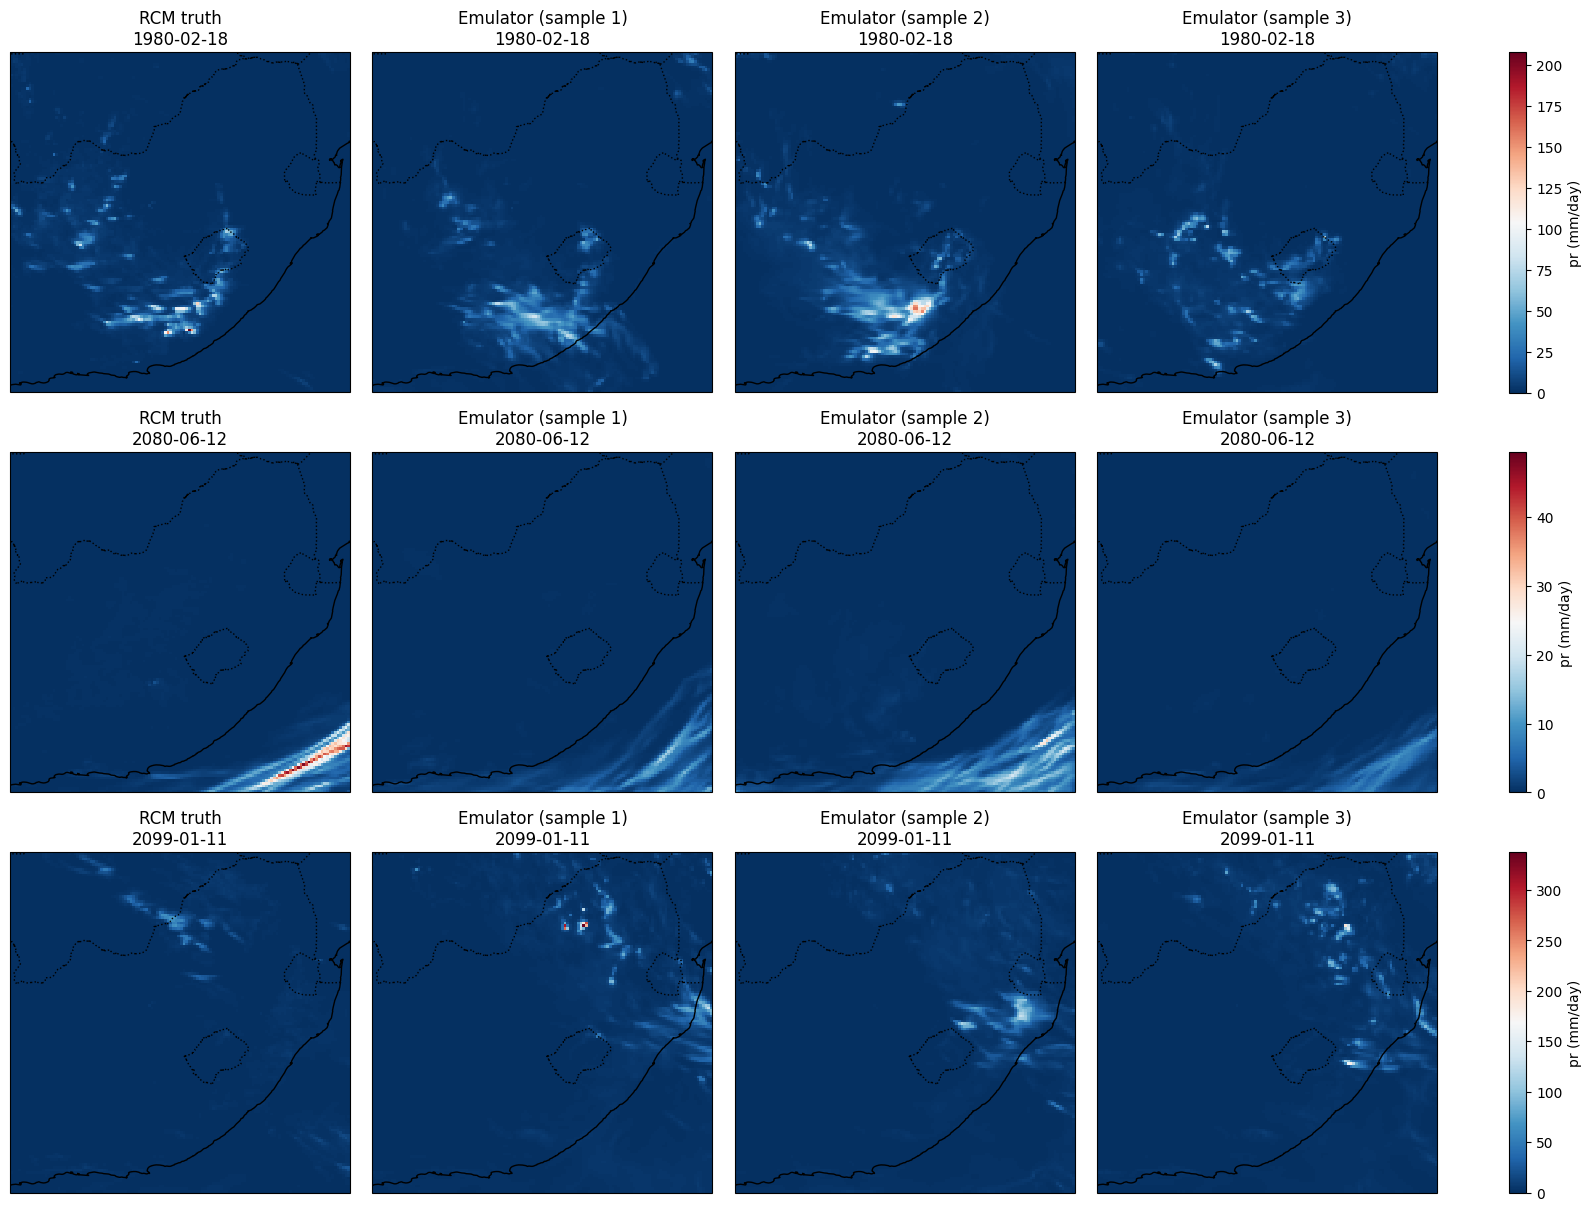

In [32]:
def plot_random_day_comparison(
    ds_predictions,
    target: str,
    n_days: int = 3,
    seed: int | None = None,
    cmap: str = "YlGnBu",
):

    units = {"pr": "mm/day"}
    unit_label = units.get(target, target)
    vmin = 0

    n_samples = ds_predictions.sizes["sample"]
    n_cols = n_samples + 1

    if seed is not None:
        np.random.seed(seed)
    all_times = ds_predictions.time.values
    selected_times = np.sort(all_times[np.random.choice(len(all_times), size=n_days, replace=False)])

    fig, axes = plt.subplots(
        n_days, n_cols,
        figsize=(4 * n_cols, 4 * n_days),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )
    if n_days == 1:
        axes = axes[np.newaxis, :]  # ensure 2D indexing for single day

    for i, t in enumerate(selected_times):
        date_str = np.datetime_as_string(t, unit="D")

        da_target = ds_predictions[f"target_{target}"].sel(input=experiment, time=t)
        das = [da_target] + [
            ds_predictions[f"pred_{target}"].sel(sample=s, input=experiment, time=t)
            for s in range(n_samples)
        ]
        titles = ["RCM truth"] + [
            "Emulator" if n_samples == 1 else f"Emulator (sample {s+1})"
            for s in range(n_samples)
        ]

        vmax = float(np.nanmax([da.values for da in das]))

        for ax, da, title in zip(axes[i], das, titles):
            im = da.plot(
                ax=ax, cmap=cmap, transform=ccrs.PlateCarree(),
                vmin=vmin, vmax=vmax, add_colorbar=False,
            )
            ax.coastlines(resolution="10m")
            ax.add_feature(cfeature.BORDERS, linestyle=":")
            ax.set_title(f"{title}\n{date_str}")

        fig.colorbar(im, ax=axes[i, :], orientation="vertical", label=f"{target} ({unit_label})")

    plt.show()


# PLot
plot_random_day_comparison(ds_predictions, target = 'pr', n_days=3, seed=42, cmap="RdBu_r")

## 8. Next steps

You have now run inference with a pretrained flow matching downcaling model and visualised the predictions against the RCM target. Ideas for next steps:

- Re-run the notebook with the other experiment and compare the predicitions. For the model trained only on historical data, how good a job does it do at extrapolating and making predictions in the future?
- How does this generative model compare with the deterministic UNet model?
- Try changing the number of samples produced - how much variability is there in the generative model predictions?
- Try different model settings such as the number of time steps for the ODE solver
- Plot the intermediate states of the flow - can you see the precipitaion field emerging from the noise?